# Causal Inference(A/B TEST) with Simulation

The purpose of this project is building a simulated dataset to study causal inference in A/B testing. First, 
we define potential outcomes (Y0 and Y1) to represent consumer spending with and without ads, allowing to compute the 
true treatment effect. We then show how non-random ad exposure creates selection bias, making simple comparisons 
misleading. Next,a randomized experiment was introcuced to assign ads randomly, removing this bias. Finally, we estimate
the treatment effect using experimental data and compare it to the true effect.

We are going to create a data set from the point of view of an “omniscient observer”, which means we have all the information about 1) how the algorithm makes decisions about advertisement for each consumer 2) the potential outcomes for each consumer or in another word we can see the parellel worlds in which we monitoring both control and treated group 
at the same time. 

We start with initializing the following data set for 1000 consumers by running the code below. In this data set we will see 3 variables:

- **consumer_ID**: a number indexing the consumer  
- **distance**: the consumer number of miles the consumer lives from the restaurant  
- **past_spend**: the amount the consumer has previously spent at the restaurant

In [ ]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:

n = 1000

distance = np.random.uniform(low=0, high=20, size=n)
past_spend = np.random.uniform(low=30, high=70, size=n)
consumer_ID = np.arange(0, n) 

df = pd.DataFrame({
    'consumer_ID': consumer_ID,
    'distance': distance,
    'past_spend': past_spend
})

df.head()

,consumer_ID,distance,past_spend
0,0,6.020655,31.123641
1,1,17.853614,51.534707
2,2,8.933446,62.735123
3,3,13.660901,43.063395
4,4,18.942561,40.572343


Now we will create a new variable in the data frame that shows whether the consumer saw a display ad for the given 
restaurant. The consumer would have seen a display ad if:

1-They live within 10 miles of the restaurant

2-They spent more than 50 dollars in the last month at the restaurant

We name this variable “see_ad”

The important point here is that the tretament assignment is not random so it will create selection bias. 

In [9]:
df['see_ads']= ((df['distance']<=10) & (df['past_spend']>=50)).astype(int)
df

,consumer_ID,distance,past_spend,see_ads
0,0,6.020655,31.123641,0
1,1,17.853614,51.534707,0
2,2,8.933446,62.735123,1
3,3,13.660901,43.063395,0
4,4,18.942561,40.572343,0
...,...,...,...,...
995,995,11.398925,61.857045,0
996,996,7.386690,51.192436,1
997,997,3.261439,35.527535,0
998,998,16.124162,62.639607,0


# Potential outcome 


We will create a varaible 'Y0' to represent the amount the consumer will spend at this restaurant over the next month if there were no ads. We will assume this is the same amount they spent in the last month with additional some random noise (normally distributed, mean =0, st_dev = 5 dollars)

We will create a variable 'Y1' to represent represent the amount the consumer will spend if they are adveritised to. Assume that consumers that live closer to the restaurantare more responsive to ads, as they will order more frequently due to short delivery times. The data generating process follows:

- a consumer that lives more that 10 miles away, will spend an additional 10 dollars per month on average. You can assume that this additional spend is normally distributed, with a standard deviation of 2 dollars.

- a consumer that lives less then 10 miles away will spend and additional an additioanl 20 dollars per month on average. You can assume that this additional spend is normally distributed, with a standard deviation of 4 dollars.


In [10]:
# Y0

df['Y0'] = df['past_spend'] + np.random.normal(0, 5, len(df))
df['Y0']

0      35.484294
1      42.386061
2      70.640064
3      37.514804
4      54.695126
         ...    
995    61.835429
996    50.980654
997    40.662360
998    53.090201
999    37.974931
Name: Y0, Length: 1000, dtype: float64

In [13]:
df['ad_effect'] = 0
df['ad_effect']

0      0
1      0
2      0
3      0
4      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: ad_effect, Length: 1000, dtype: int64

In [15]:
# Far customers (>10 miles)
far_away = df["distance"] > 10

0      False
1       True
2      False
3       True
4       True
       ...  
995     True
996    False
997    False
998     True
999    False
Name: distance, Length: 1000, dtype: bool

In [21]:
# close customers 
close_by = df["distance"] <= 10
close_by

0       True
1      False
2       True
3      False
4      False
       ...  
995    False
996     True
997     True
998    False
999     True
Name: distance, Length: 1000, dtype: bool

In [ ]:
# Far away customers >10
df.loc[df['distance'] > 10, 'ad_effect'] = np.random.normal(10, 2, sum(df['distance'] > 10)) 

In [17]:
# Close customers (≤10 miles)
df.loc[df['distance'] <= 10, 'ad_effect'] = np.random.normal(20, 4, sum(df['distance'] <= 10))

In [19]:
df['Y1'] = df['Y0'] + df['ad_effect']
df

,consumer_ID,distance,past_spend,see_ads,Y0,ad_effect,Y1
0,0,6.020655,31.123641,0,35.484294,24.148470,59.632764
1,1,17.853614,51.534707,0,42.386061,10.748779,53.134840
2,2,8.933446,62.735123,1,70.640064,21.890606,92.530669
3,3,13.660901,43.063395,0,37.514804,13.355711,50.870515
4,4,18.942561,40.572343,0,54.695126,10.000086,64.695212
...,...,...,...,...,...,...,...
995,995,11.398925,61.857045,0,61.835429,9.229388,71.064817
996,996,7.386690,51.192436,1,50.980654,24.300896,75.281550
997,997,3.261439,35.527535,0,40.662360,14.499206,55.161565
998,998,16.124162,62.639607,0,53.090201,10.782661,63.872862


In [23]:
# Potentioal outcome

df["Y"] = df["see_ads"] * df["Y1"] + (1 - df["see_ads"]) * df["Y0"]
# Y1=1 menas it was exposed to advertise 

df.head()

,consumer_ID,distance,past_spend,see_ads,Y0,ad_effect,Y1,Y
0,0,6.020655,31.123641,0,35.484294,24.148470,59.632764,35.484294
1,1,17.853614,51.534707,0,42.386061,10.748779,53.134840,42.386061
2,2,8.933446,62.735123,1,70.640064,21.890606,92.530669,92.530669
3,3,13.660901,43.063395,0,37.514804,13.355711,50.870515,37.514804
4,4,18.942561,40.572343,0,54.695126,10.000086,64.695212,54.695126


In [27]:
# the percent of consumers saw an ad?

df['see_ads'].mean() * 100

23.200000000000003

In [29]:
#the average of Y0?
#the average of Y1?
#the average of Y?

average_Y0 = df["Y0"].mean()
average_Y1 = df["Y1"].mean()
average_Y = df["Y"].mean()

average_Y0, average_Y1, average_Y

(49.346942122301265, 64.45331914441984, 53.99519492131729)

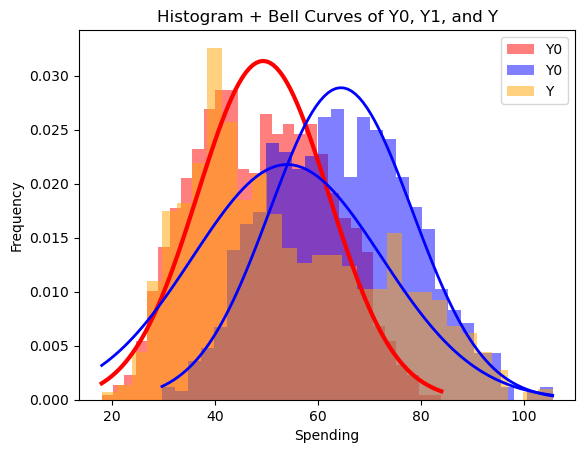

In [37]:
# Visualization of Y0,Y1,Y


from scipy.stats import norm

plt.hist(df['Y0'], bins=30, alpha=0.5, label='Y0', color='red', density=True)
plt.hist(df['Y1'],bins=30, alpha=0.5, label='Y0', color='blue', density=True)
plt.hist(df['Y'],bins=30,alpha=0.5,label='Y', color='orange', density=True)

mean_Y0, std_Y0= df['Y0'].mean(), df['Y0'].std()
x_Y0=np.linspace(df['Y0'].min(), df['Y0'].max(),100)
plt.plot(x_Y0, norm.pdf(x_Y0,mean_Y0,std_Y0), color='red', linewidth=3)

mean_Y1, std_Y1=df['Y1'].mean(), df['Y1'].std()
x_Y1=np.linspace(df['Y1'].min(), df['Y1'].max(), 100)
plt.plot(x_Y1,norm.pdf(x_Y1,mean_Y1, std_Y1), color='blue', linewidth=2)


mean_Y, std_Y=df['Y'].mean(), df['Y'].std()
x_Y=np.linspace(df['Y'].min(), df['Y'].max(), 100)
plt.plot(x_Y,norm.pdf(x_Y,mean_Y, std_Y), color='blue', linewidth=2)

plt.legend()
plt.title('Histogram + Bell Curves of Y0, Y1, and Y')
plt.xlabel('Spending')
plt.ylabel('Frequency')
plt.show()

In [43]:
# simple difference=  average spending outcome (Y) for people who saw the ad and people who did not

see_adds=df[df['see_ads']==1]['Y'].mean()
see_no_adds=df[df['see_ads']==0]['Y'].mean()

difference = see_adds - see_no_adds
                              
difference, see_adds, see_no_adds

(33.923121286408545, 80.04815206927906, 46.12503078287051)

$$
E[Y \mid D = 1] - E[Y \mid D = 0]
=
\underbrace{E[Y_1 - Y_0]}_{\text{True effect}}
+
\underbrace{E[Y_0 \mid D = 1] - E[Y_0 \mid D = 0]}_{\text{Selection bias}}
$$


The difference is The difference is **People who saw the ad spent more than people who didn’t.**

so the difference refelcet both true effect and selection bias. 

In [45]:
# selection bias 

average_Y0_saw_ad = df[df["see_ads"] == 1]["Y0"].mean()
average_Y0_did_not_see_ad = df[df["see_ads"] == 0]["Y0"].mean()

selection_bias = average_Y0_saw_ad - average_Y0_did_not_see_ad
average_Y0_saw_ad, average_Y0_did_not_see_ad, selection_bias

(60.0125796597272, 46.12503078287051, 13.887548876856691)

### Selection Bias

Selection bias means:

$$
E[Y_0 \mid \text{see_ad} = 1] - E[Y_0 \mid \text{see_ad} = 0]
$$

> it is going to answer :  “Even **without ads**, are these two groups different?”

---

### Intuition

- This is the case where we **have not applied the effect of ads**, or we imagine a world where **no one sees the ads**.
- It measures:
  
  **Are these groups already different before treatment?**

---

### Where does this difference come from?

It comes from how we assign treatment:


see_ad = (distance <= 10) & (past_spend > 50)


People who see ads:
    
1-live closer

2- already spend more

so we can say add assignments not random.

In simpler words,selection_bias = pre-existing difference and the difference we calculated above is not ATE we are looking for becuase it was polluted by pre-existing differences.

As a result because tretament and control group are not comparable( like RCT ), the simplae difference calculated above 
is biased and people who saw ads were already “better customers” and different from the people who did not. 

In [47]:
# ATE 
true_effect = (df['Y1'] - df['Y0']).mean()
true_effect

15.10637702211857

it is not possible to compute true_effect in this way . I mean by having Y1 and Y0 because :
    
For each person, we only observe one outcome:
If they saw the ad → we observe Y1
If they didn’t → we observe Y0
We never observe both for the same person
This is called:
the fundamental problem of causal inference

true_effect = difference - selection bias


so inreality we can compute for difference but we can not for selection bias so we try to make selection bias =0
and thats why we almost use A/B testing to make Observed Difference=True Effect

In [49]:
# ATT (Average Treatment Effect on the Treated)
ATT=(df[df['see_ads']==1]['Y1']-df[df['see_ads']==1]['Y0']).mean()
ATT

20.03557240955184

Again we can compute ATT here only because it's simulated process. 
In real life:
we don’t observe both Y1 and Y0 for the same person.
so ATT is not directly observable.

In [50]:
# heterogenous tretament effect 

#  groups based on distance
close_by = df["distance"] <= 10
far_away = df["distance"] > 10

#  the average treatment effect for each group
treatment_effect_close = df[close_by]["Y1"].mean() - df[close_by]["Y0"].mean()
treatment_effect_far = df[far_away]["Y1"].mean() - df[far_away]["Y0"].mean()

treatment_effect_close, treatment_effect_far

(20.01905594168298, 10.033936186470775)

Heterogenous Treatment effect means the tretament effect(ads) is NOT the same for everyone and its effect can be different
for the people who are see the ads but living close and far from the resturants or for example the ads effect can be 
different for people with different gender or different range of age. 

# 1.For Consumers within 10 miles:

These consumers are closer to the restaurant, which likely means faster delivery times and greater
convenience. As a result, they are more responsive to the ad. In other words, the ad has a stronger impact on their spending.
Expected Spending Increase: On average, these consumers are expected to spend $20 more per month after seeing the
ad (with some variation due to the random component). This suggests a larger treatment effect for consumers who
live nearby.

# 2. For Consumers more than 10 miles away:

These consumers live farther from the restaurant, so they may face longer delivery times or higher
delivery costs. Consequently, the ad has a smaller impact on their spending.
Expected Spending Increase: On average, these consumers are expected to spend $10 more per month after seeing the 
ad. This represents a smaller treatment effect compared to consumers who live closer to the restaurant.

Aagain we can not compute this effect in this way and in real-world case we need methods like stratification, regression,CATE models like causal ML.  






So far We have created data from our data generating process as an omniscient observer and calculated the average 
treatment effect knowing Y0 and Y1. Now, we want to see what would happen if we could not observe Y0 and Y1 (the fundamental problem of causal inference) and instead relied on experiments. In the following section we will simulate experiments multiple times and confirm that they help reveal the average treatment effect.

In [51]:
# We will Create a new variable experiment_ad, where a random 50% percent of users are treated with the ad and the other
# 50% are not.

# #  Randomly assign 50% of consumers to see the ad (1) and 50% not to see the ad (0)

df['experiment_ad'] = np.random.choice([0, 1], size=len(df))
df

,consumer_ID,distance,past_spend,see_ads,Y0,ad_effect,Y1,Y,experiment_ad
0,0,6.020655,31.123641,0,35.484294,24.148470,59.632764,35.484294,0
1,1,17.853614,51.534707,0,42.386061,10.748779,53.134840,42.386061,0
2,2,8.933446,62.735123,1,70.640064,21.890606,92.530669,92.530669,0
3,3,13.660901,43.063395,0,37.514804,13.355711,50.870515,37.514804,0
4,4,18.942561,40.572343,0,54.695126,10.000086,64.695212,54.695126,0
...,...,...,...,...,...,...,...,...,...
995,995,11.398925,61.857045,0,61.835429,9.229388,71.064817,61.835429,0
996,996,7.386690,51.192436,1,50.980654,24.300896,75.281550,75.281550,0
997,997,3.261439,35.527535,0,40.662360,14.499206,55.161565,40.662360,1
998,998,16.124162,62.639607,0,53.090201,10.782661,63.872862,53.090201,0


In [52]:
df['experiment_ad'].mean()

0.511

In [54]:
# Creating a new variable experiment_y which is the observed outcome for each user from this hypothetical experiment. 

df["experiment_y"] = df["experiment_ad"] * df["Y1"] + (1 - df["experiment_ad"]) * df["Y0"]
df.head()

,consumer_ID,distance,past_spend,see_ads,Y0,ad_effect,Y1,Y,experiment_ad,experiment_y
0,0,6.020655,31.123641,0,35.484294,24.148470,59.632764,35.484294,0,35.484294
1,1,17.853614,51.534707,0,42.386061,10.748779,53.134840,42.386061,0,42.386061
2,2,8.933446,62.735123,1,70.640064,21.890606,92.530669,92.530669,0,70.640064
3,3,13.660901,43.063395,0,37.514804,13.355711,50.870515,37.514804,0,37.514804
4,4,18.942561,40.572343,0,54.695126,10.000086,64.695212,54.695126,0,54.695126


In [55]:
# Calculating the average treatment effect from this experiment using the simple difference in outcomes

average_experiment_y_treated = df[df["experiment_ad"] == 1]["experiment_y"].mean()
average_experiment_y_control = df[df["experiment_ad"] == 0]["experiment_y"].mean()

# the ATE from the experiment
experimental_ATE = average_experiment_y_treated - average_experiment_y_control

average_experiment_y_treated, average_experiment_y_control, experimental_ATE

(64.7994023676462, 49.0460658310354, 15.753336536610796)

As we can see here here experimental_ATE is equal true effect (ATE) calculated above which showing when the assignment is 
random , we do not have selection bias we can return to true ATE. They are not exactly same and that  small difference is due to random variation in the sample which in the next section we try to repaet oe simulate sampling 1000 to see its value
on all these 1000 times. 

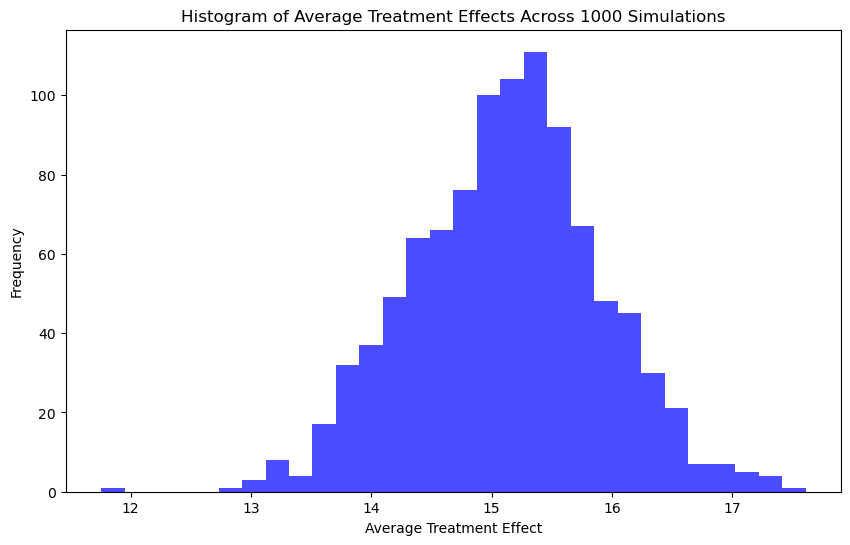

(15.12074639655801, (11.755033581336946, 17.6080152958191))

In [59]:
# Initializing
ATE_list = []

# Repeating the experiment 1000 times
for _ in range(1000):
    
    df["experiment_ad"] = np.random.choice([0, 1], size=len(df), p=[0.5, 0.5])
    

    df["experiment_y"] = df["experiment_ad"] * df["Y1"] + (1 - df["experiment_ad"]) * df["Y0"]
    
    
    average_experiment_y_treated = df[df["experiment_ad"] == 1]["experiment_y"].mean()
    average_experiment_y_control = df[df["experiment_ad"] == 0]["experiment_y"].mean()
    ATE = average_experiment_y_treated - average_experiment_y_control
    
    # Storing the ATE
    ATE_list.append(ATE)


mean_ATE = np.mean(ATE_list)

plt.figure(figsize=(10, 6))
plt.hist(ATE_list, bins=30, alpha=0.7, color='blue')
plt.title("Histogram of Average Treatment Effects Across 1000 Simulations")
plt.xlabel("Average Treatment Effect")
plt.ylabel("Frequency")
plt.show()


ATE_range = (min(ATE_list), max(ATE_list))

mean_ATE, ATE_range

This graph showing the ATE values will vary slightly across experiments due to random sampling. This variability is expected even if the true ATE is constant, because each experiment might randomly assign slightly different consumers to the treatment and control groups or in other word each sample is different. 


The mean ATE across all experiments should be close to the true ATE . This indicates that, on average, the experiment correctly estimates the treatment effect.

The range of ATEs shows how much the estimated treatment effect can vary in different experiments. The range can 
help understand the potential uncertainty in any single experiment's result.

The histogram illustrates that while the average ATE across many experiments will be close to the true value, individual experiments may yield slightly different results. This is due to  randomness in assigning treatment and control groups. It highlights the fact that the outcome of any single experiment may not perfectly represent the true treatment effect, but running multiple experiments or having a large sample size can provide a more accurate estimate.